In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

[28.62390888]
-2.066789822957533


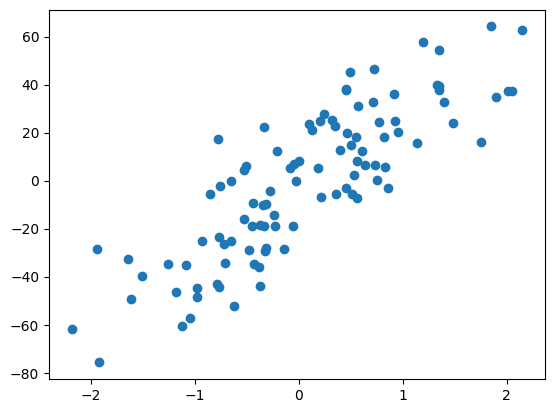

In [62]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.104e+04, tolerance: 8.063e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the

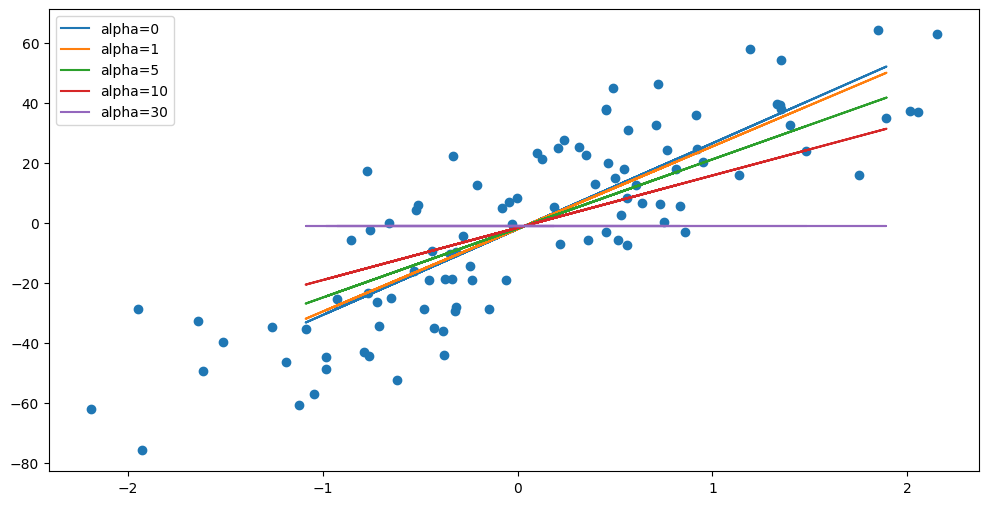

In [63]:
alphas = [0,1,5,10,30]
plt.figure(figsize=(12,6))
plt.scatter(X,y)
for i in alphas:
    L = Lasso(alpha=i)
    L.fit(X_train,y_train)
    plt.plot(X_test, L.predict(X_test), label='alpha={}'.format(i))
plt.legend()
plt.show()

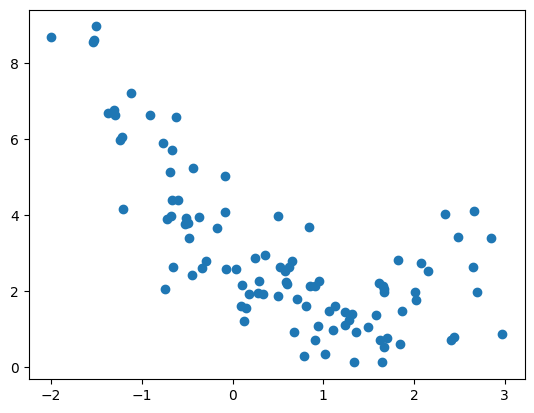

In [64]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()


In [65]:
lr = LinearRegression()
lr.fit(x1, x2)
print(lr.coef_)
print(lr.intercept_)

[[-1.22315286]]
[3.62421135]


Coefficients [ 0.00000000e+00 -1.81184271e+00  6.12171236e-01 -2.36667707e-01
  1.15143593e-01  2.22504566e-02 -1.63228656e-02  5.32898409e-03
 -2.03112351e-03  6.29069937e-04 -1.48470732e-04  5.18328391e-05
 -1.01932169e-05  2.95377798e-06 -9.32042173e-07  2.98072123e-08
 -1.18695871e-07]
Intercept [2.83696179]
Coefficients [ 0.00000000e+00 -1.53382029e+00  0.00000000e+00 -2.09140681e-01
  2.83016072e-01 -1.35111010e-02 -1.18285655e-02  2.85087327e-03
 -3.12453843e-03  1.17596818e-03 -3.11296220e-04  1.05257139e-04
 -2.18935381e-05  6.63357210e-06 -1.64962471e-06  2.50150409e-07
 -1.61671792e-07]
Intercept [3.08748824]
Coefficients [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
  0.00000000e+00 -0.00000000e+00  0.00000000e+00 -1.50871343e-02
  0.00000000e+00 -1.91407849e-05  1.45238187e-03 -2.12647242e-04
  6.47898230e-05 -1.90318753e-05  1.53591356e-06 -1.63688707e-06
 -1.30407450e-07]
Intercept [3.05722894]
Coefficients [ 0.00000000e+00  0.00000000e+00  0.00000000e

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.421e+01, tolerance: 4.219e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the

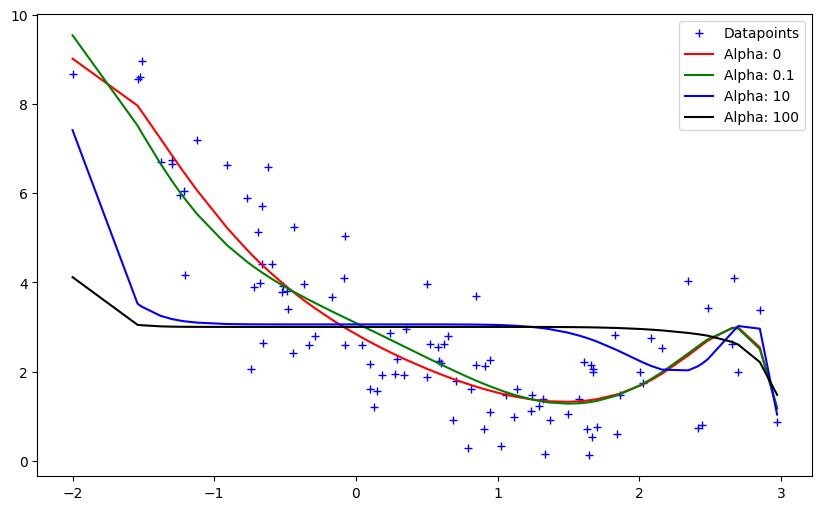

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

def get_preds_lasso(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('lasso', Lasso(alpha=alpha))
    ])
    model.fit(x1, x2)
    # print(f"Coefficients {model.named_steps['lasso'].coef_}")
    # print(f"Intercept {model.named_steps['lasso'].intercept_}")
    return model.predict(x1)

alphas = [0, 0.1, 10, 100]
cs = ['r', 'g', 'b', 'k']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_lasso(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()